# Project 6 - Working with SQL

## Step 4 - Exploratory data analysis (Python)

In addition to the data retrieved in previous tasks, a second file was assigned for analysis which contained the following two CSVs:

1) `/datasets/project_sql_result_01.csv`, which contains:  
    - `company_name`: the taxi company name, and  
    - `trips_amount`: the number of rides for each taxi company on November 15-16, 2017.  

2) `/datasets/project_sql_result_04.csv`, which contains:  
    - `dropoff_locations_name`: Chicago neighborhoods where rides ended, and  
    - `average_trips`: the average number of rides that ended in each neighborhood in November 2017.  

For those two CSVs, the following tasks need to be performed:

1. Importing the files;
2. Studying the data contained by each;
3. Identifying the top 10 neighborhoods in terms of drop-offs;
4. Making graphs, such as "Taxi Companies and Number of Rides" and "The Top 10 Neighborhoods by Number of Drop-offs";
5. Drawing conclusions based on each graph, and explaining the results; 

In [1]:
# Importing the libraries to perform tasks with

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind

In [2]:
# Task 1: Importing the files

df1 = pd.read_csv('/datasets/project_sql_result_01.csv')

df4 = pd.read_csv('/datasets/project_sql_result_04.csv')

In [3]:
# Converting column names to lowercase

df1.columns = df1.columns.str.lower()
df4.columns = df4.columns.str.lower()

#### Summary of Task 1:

In order to access the data contained by the datasets, Task 1 entailed carrying out the following actions:
- Importing all needed libraries to perform tasks for Step 4 with.
- Importing the files by loading the datasets to be studied.
- Converting column names in the datasets and files to lowercase.

In [4]:
# Task 2: Studying the data contained by each file

In [5]:
## Using `.info()` and to get a summary of the data types in df1

print(df1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None


In [6]:
## Using `.info()` and to get a summary of the data types in df4

print(df4.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None


In [7]:
## Using `.head()` to get an overview of the first 10 entries in df1

print(df1.head())

                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299


In [8]:
## Using `.head()` to get an overview of the first 10 entries in df4

print(df4.head())

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000


In [9]:
## Using `.tail()` to get an overview of the last 10 entries in df1

print(df1.tail())

                     company_name  trips_amount
59   4053 - 40193 Adwar H. Nikola             7
60        2733 - 74600 Benny Jona             7
61  5874 - 73628 Sergey Cab Corp.             5
62     2241 - 44667 - Felman Corp             3
63    3556 - 36214 RC Andrews Cab             2


In [10]:
## Using `.tail()` to get an overview of the last 10 entries in df4

print(df4.tail())

   dropoff_location_name  average_trips
89       Mount Greenwood       3.137931
90             Hegewisch       3.117647
91              Burnside       2.333333
92             East Side       1.961538
93             Riverdale       1.800000


In [11]:
## Using `describe()` to get basic statistics like `mean` and `count` in df1

print(df1.describe())

       trips_amount
count     64.000000
mean    2145.484375
std     3812.310186
min        2.000000
25%       20.750000
50%      178.500000
75%     2106.500000
max    19558.000000


In [12]:
## Using `describe()` to get basic statistics like `mean` and `count` in df4

print(df4.describe())

       average_trips
count      94.000000
mean      599.953728
std      1714.591098
min         1.800000
25%        14.266667
50%        52.016667
75%       298.858333
max     10727.466667


In [13]:
## Checking for missing values in df1

print(df1.isnull().sum())

company_name    0
trips_amount    0
dtype: int64


In [14]:
## Checking for missing values in df4

print(df4.isnull().sum())

dropoff_location_name    0
average_trips            0
dtype: int64


In [15]:
## Checking for duplicates in df1

print(df1.duplicated().sum())

0


In [16]:
## Checking for duplicates in df4

print(df4.duplicated().sum())

0


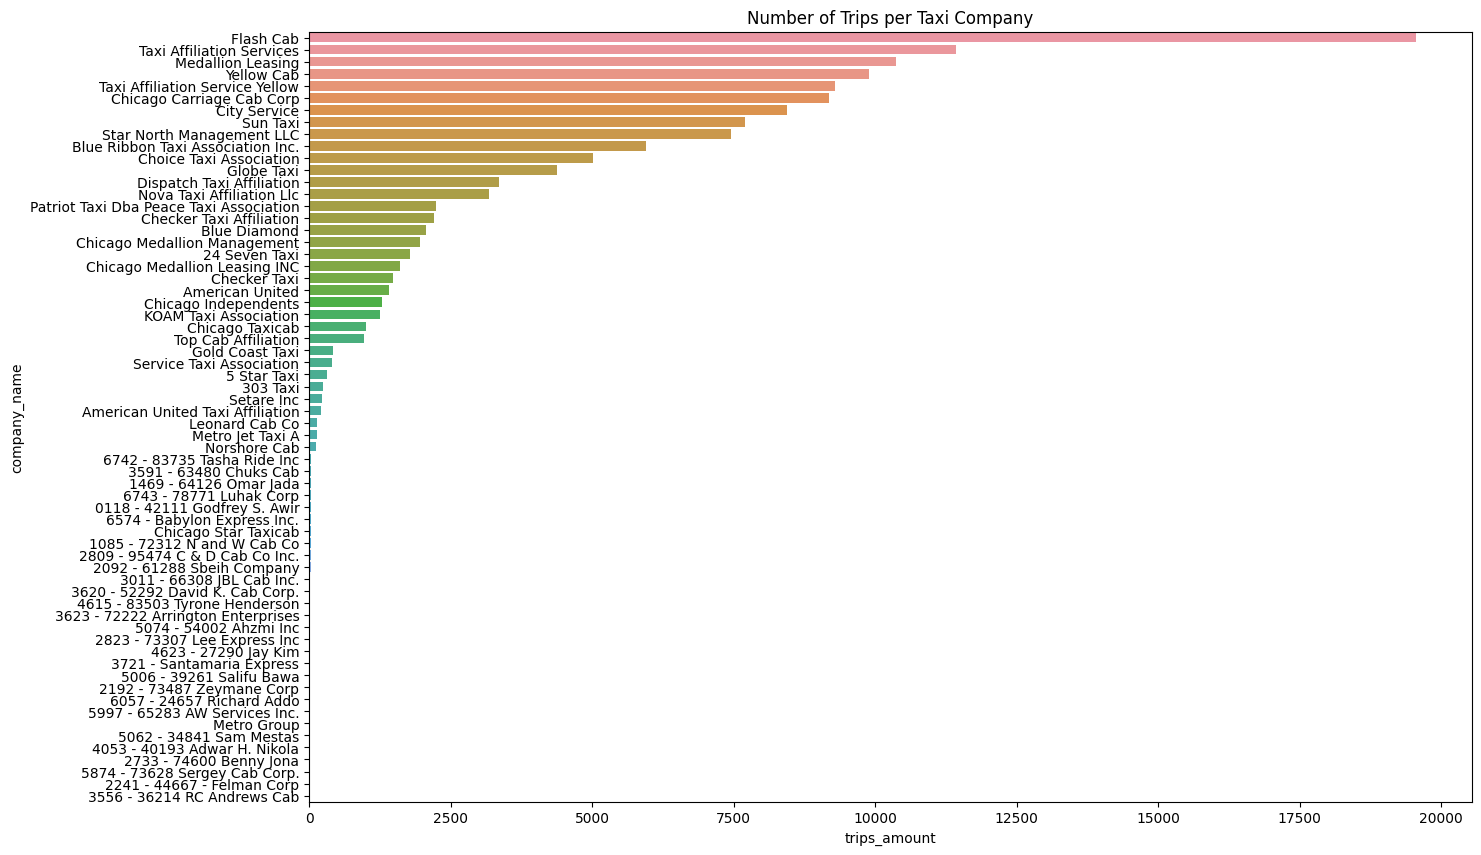

In [17]:
## Visualizing the number of trips for each company in df1

plt.figure(figsize=(15,10))
sns.barplot(x='trips_amount', y='company_name', data=df1.sort_values(by='trips_amount', ascending=False))
plt.title('Number of Trips per Taxi Company')
plt.rc('font', size=10)             # Default text size
plt.rc('axes', titlesize=12)        # Title font size
plt.rc('axes', labelsize=10)        # Axis label font size
plt.rc('xtick', labelsize=8)        # X-tick label font size
plt.rc('ytick', labelsize=8)        # Y-tick label font size
plt.rc('legend', fontsize=10)       # Legend font size
plt.show()

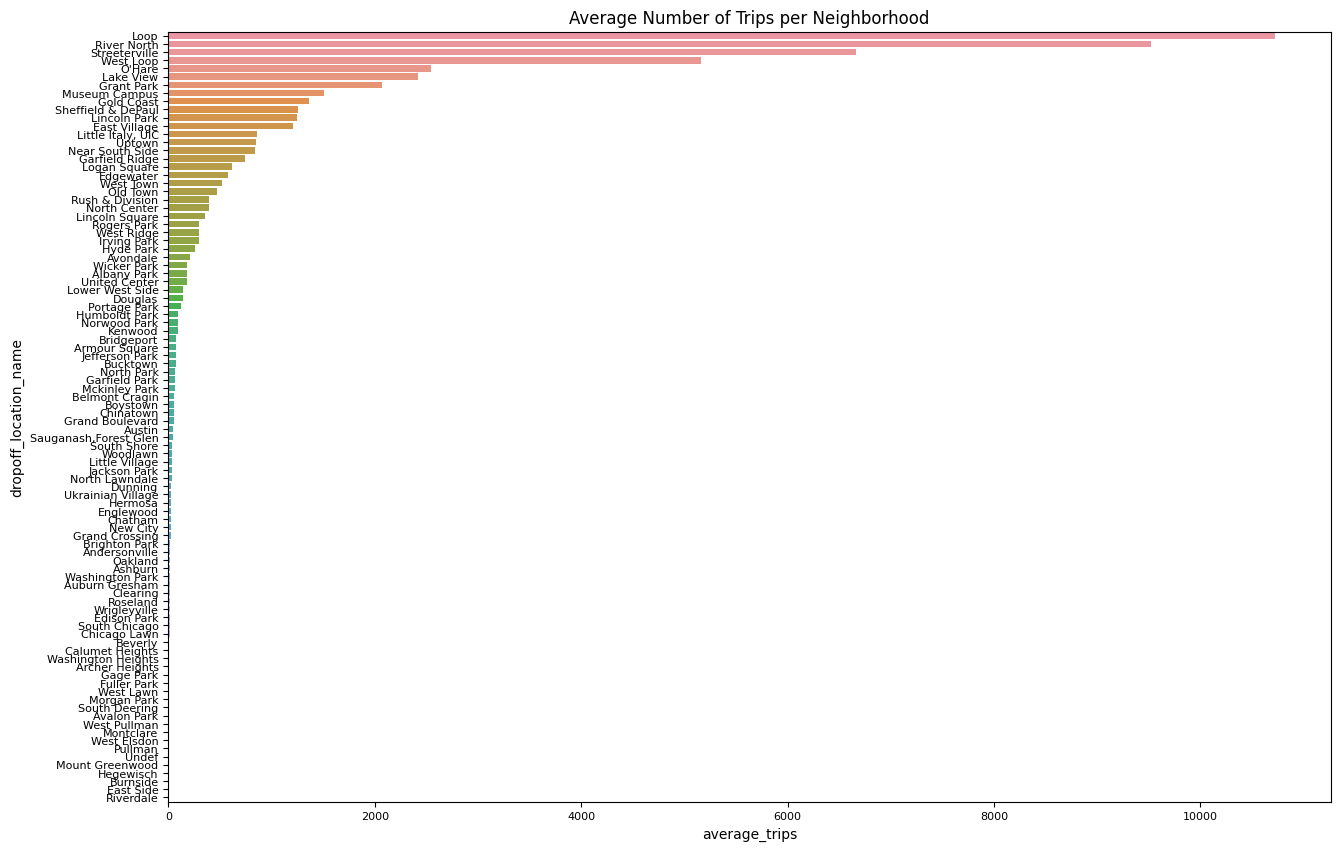

In [18]:
## Visualizing the number of trips for each company in df4

plt.figure(figsize=(15,10))
sns.barplot(x='average_trips', y='dropoff_location_name', data=df4.sort_values(by='average_trips', ascending=False))
plt.title('Average Number of Trips per Neighborhood')
plt.rc('font', size=10)             # Default text size
plt.rc('axes', titlesize=12)        # Title font size
plt.rc('axes', labelsize=10)        # Axis label font size
plt.rc('xtick', labelsize=8)        # X-tick label font size
plt.rc('ytick', labelsize=8)        # Y-tick label font size
plt.rc('legend', fontsize=10)       # Legend font size
plt.show()

#### Summary of Task 2:

In order to study the data contained by each file, Task 2 entailed carrying out the following actions:

- Using `.info()` and to get a summary of the data types.
- Using `.head()` to get an overview of the first 10 entries.
- Using `.tail()` to get an overview of the last 10 entries.
- Using `describe()` to get basic statistics like `mean` and `count`.
- Checking for missing values.
- Visualizing the number of trips for each company.

In [19]:
# Task 3: Indetifying the top 10 neighborhoods in terms of drop-offs

In [20]:
## Sorting by 'average_trips' in descending order

top_neighborhoods = df4.sort_values(by='average_trips', ascending=False).head(10)

## Displaying the top 10 neighborhoods with the most drop-offs
                                    
print(top_neighborhoods)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


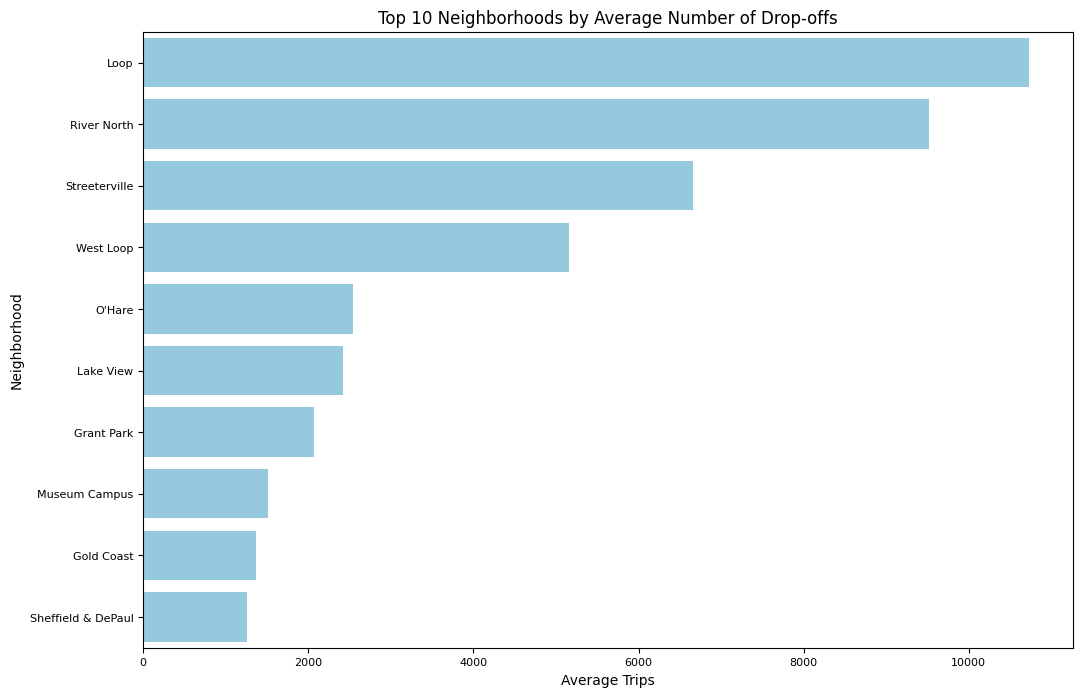

In [21]:
## Visualizing results to understand the data distribution and making comparisons

plt.figure(figsize=(12, 8))
sns.barplot(x='average_trips', y='dropoff_location_name', data=top_neighborhoods, color='skyblue')
plt.title('Top 10 Neighborhoods by Average Number of Drop-offs')
plt.xlabel('Average Trips')
plt.ylabel('Neighborhood')
plt.show()

#### Summary of Task 3:

In order to identify the top 10 neighborhoods in terms of drop-offs, Task 3 entailed carrying out the following actions:
- Using the `sort_values()` method to sort the `df4` dataframe by the `average_trips` column in descending order.
- Using the `head(10)` method to select the top 10 rows from the sorted dataframe.
- Creating a bar plot to visualize the top 10 neighborhoods with the most drop-offs.

In [22]:
# Task 4: Making graphs, such as "Taxi Companies and Number of Rides" and "The Top 10 Neighborhoods by Number of Drop-offs"

In [23]:
## Checking for missing values or necessary data transformations for df1

print(df1.isnull().sum())
print(df1.info())

company_name    0
trips_amount    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None


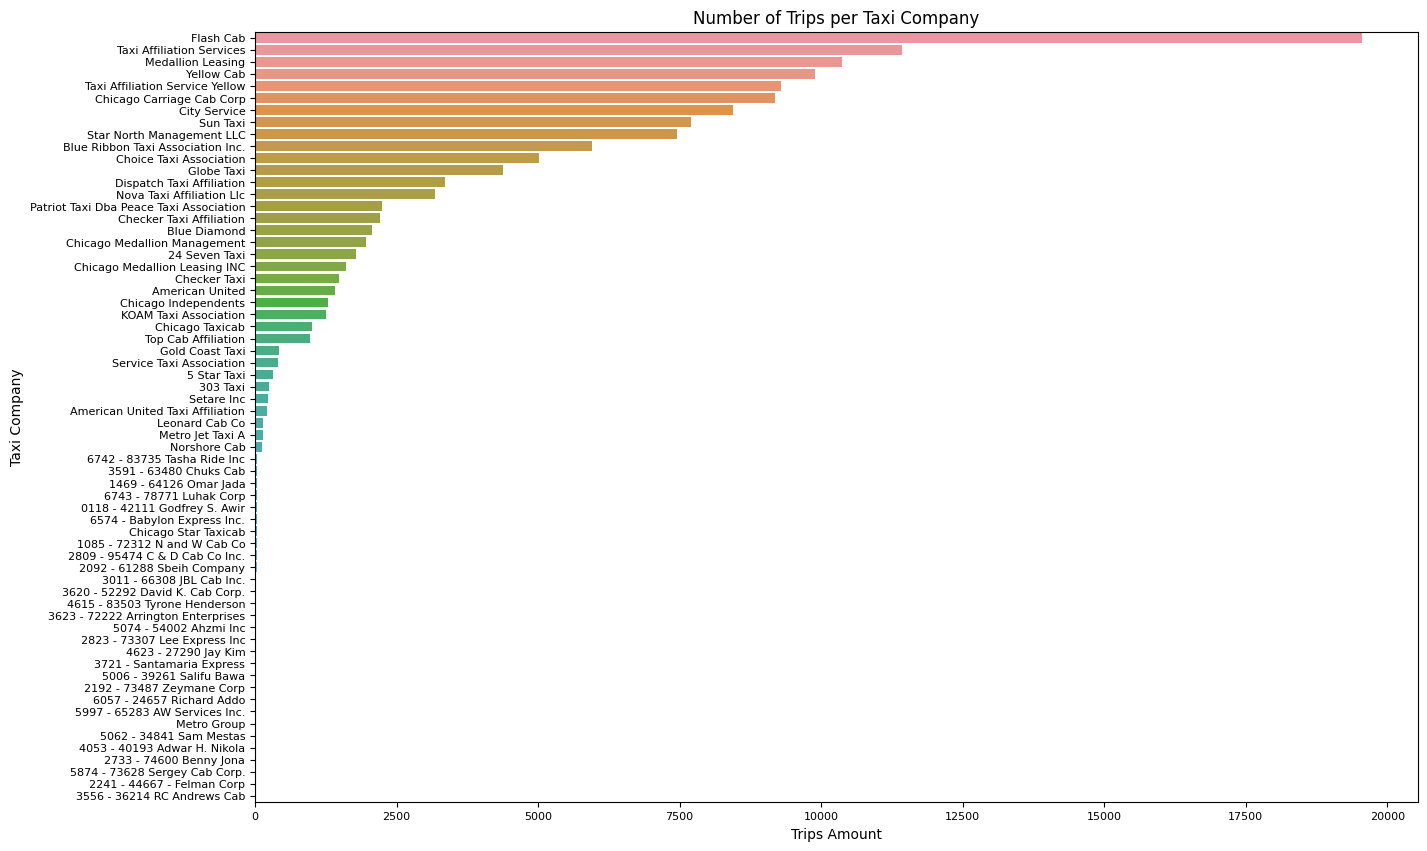

In [24]:
## Creating a bar graph for df1

plt.figure(figsize=(15, 10))
sns.barplot(x='trips_amount', y='company_name', data=df1.sort_values(by='trips_amount', ascending=False))
plt.title('Number of Trips per Taxi Company')
plt.xlabel('Trips Amount')
plt.ylabel('Taxi Company')
plt.rc('font', size=10)             # Default text size
plt.rc('axes', titlesize=12)        # Title font size
plt.rc('axes', labelsize=10)        # Axis label font size
plt.rc('xtick', labelsize=8)        # X-tick label font size
plt.rc('ytick', labelsize=8)        # Y-tick label font size
plt.rc('legend', fontsize=10)       # Legend font size
plt.show()

Graph 1: Taxi Companies and Number of Rides

In [25]:
## Checking for missing values or necessary data transformations for df4

print(df4.isnull().sum())
print(df4.info())

dropoff_location_name    0
average_trips            0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None


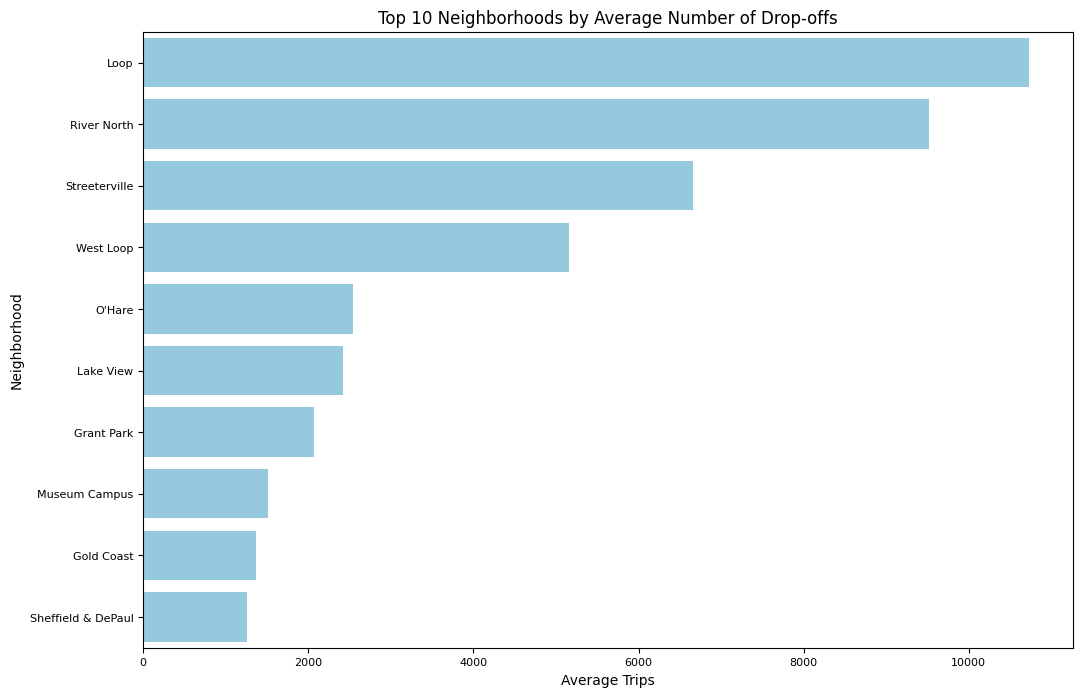

In [26]:
## Creating a graph for df4

top_neighborhoods = df4.sort_values(by='average_trips', ascending=False).head(10)
plt.figure(figsize=(12, 8))
sns.barplot(x='average_trips', y='dropoff_location_name', data=top_neighborhoods, color='skyblue')
plt.title('Top 10 Neighborhoods by Average Number of Drop-offs')
plt.xlabel('Average Trips')
plt.ylabel('Neighborhood')
plt.show()

Graph 2: Top 10 Neighborhoods by Number of Drop-offs

#### Summary of Task 4:

In order to make graphs such as 'Taxi Companies and Number of Rides' and 'The Top 10 Neighborhoods by Number of Drop-offs', Task 4 entailed carrying out the following actions:

- Checking for missing values or any necessary data transformations for both df1 and df4.
- Creating a graph for both df1 and df4.

In [27]:
# Task 5: Drawing conclusions based on each graph, and explaining the results of df1 and df4

Conclusions drawn based on "Graph 1: Taxi Companies and Number of Rides"

- As far as key performance, Flash Cab appears to led with significant trip counts.
- As far as market insights, potential growth opportunities are available to smaller companies targeting underserved areas.
- As far as business implications, smaller taxi companies could look into merging to become more competitive against larger, more establishes ones.

Conclusions drawn based on "Graph 2: Top 10 Neighborhoods by Average Number of Drop-offs"

- As far as demand analysis, the Loop and River North are the most most popular drop-off locations, suggesting high demands in these areas (potentially in terms of high commercial activity, which would make them strategic for focused marketing efforts).

- As far as trend observation, patterns in neighborhood rankings can show shifts in consumer behavior or new bustling areas. More specifically, any emerging neighborhood with increasing drop-offs could be capitalized on for future growth.

- As far as strategic recommendation, optimizing driver availability and pricing strategies in top neighborhoods maximizes profitability.

#### Summary of Task 5:

In order to draw conclusions based on each graph (i.e., "Graph 1: Taxi Companies and Number of Rides" and "Graph 2: The Top 10 Neighborhoods by Number of Drop-offs", and to explain the results of their respective dataframe (i.e., "df1" and "df4"), Task 5 entailed carrying out the following actions:

- Identifying performers, market insights, and business implications based on Graph 1.
- Analyzing demand and observing trends based on Graph 2.
- Making strategic recommendations based on both Graphs 1 and 2.

## Summary of "Step 4 - Exploratory data analysis (Python)"

In order to perform exploratory data analysis via Python, Step 4 entailed carrying out, among others, the following actions:

- Importing the necessary libraries and files to work with the assigned datasets.
- Studying the data contained by each dataset.
- Identifying the top 10 neighborhoods in terms of drop-offs.
- Making graphs, such as "Taxi Companies and Number of Rides" and "The Top 10 Neighborhoods by Number of Drop-offs".
- Drawing conclusions based on each graph, and explaining the results.

## Step 5 - Testing hypotheses (Python)

This step entails working with "the result of the last query" found in this CSV: `/datasets/project_sql_result_07.csv`. Accordingly, it contains data on rides from the Loop to O'Hare International Airport. 

In performing this step of the project, it helps to keep in mind the following:

1) `start_ts`: pickup date and time;
2) `weather_conditions`: weather conditions at the moment the ride started;
3) `duration_seconds`: ride duration in seconds;

Likewise, perfroming this step of this project will entain testing the following hypothesis:

### "The average duration of rides from the Loop to O'Hare International Airport changes on rainy Saturdays."

In doing so, decide where to set the significance level (alpha) on your own.

While working on it, ensure that the following in explained:

- How the null and alternative hypotheses were formed;
- What criterion was used to test the hypotheses and why;

In [28]:
# Loading the dataset for df7

df7 = pd.read_csv('/datasets/project_sql_result_07.csv')

In [29]:
## Checking missing values in df7

print(df7.isnull().sum())

start_ts              0
weather_conditions    0
duration_seconds      0
dtype: int64


In [30]:
## Checking for duplicates in df7

print(df7.duplicated().sum())

197


In [31]:
# These duplicates may represent multiple records of the same ride in the dataset.
# To ensure the accuracy of our analysis, any duplicate rows will be deleted, while retaining the first occurrence.

df7 = df7.drop_duplicates()

In [32]:
# Filtering rides by weather

good_weather = df7[df7['weather_conditions'] == 'Good']['duration_seconds']

bad_weather = df7[df7['weather_conditions'] == 'Bad']['duration_seconds']

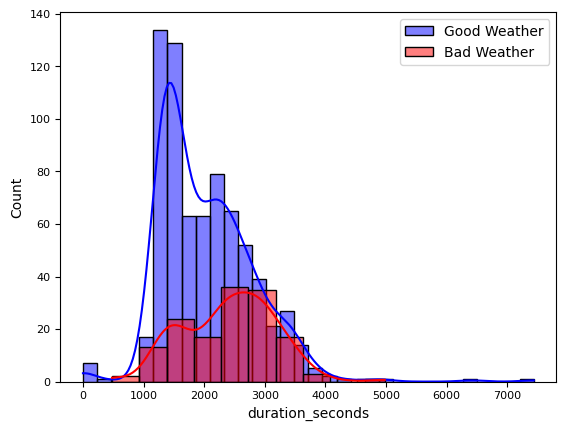

In [33]:
# Checking for normality using a simple plot

sns.histplot(good_weather, color='blue', label='Good Weather', kde=True)
sns.histplot(bad_weather, color='red', label='Bad Weather', kde=True)
plt.legend()
plt.show()

In [34]:
# Performing a t-test based on normality

t_stat, p_value = ttest_ind(good_weather, bad_weather, equal_var=False)

In [35]:
# Interpreting the result

if p_value < 0.05:
    print("Reject the null hypothesis. The average duration changes on rainy Saturdays.")
else:
    print("Fail to reject the null hypothesis. The average duration does not change on rainy Saturdays.")

Reject the null hypothesis. The average duration changes on rainy Saturdays.


#### Incorporating data insights (based on the result above)

- Since the p-value < 0.05, a significant difference in ride durations between weather conditions is present.
- From the analysis, high demand areas like the Loop are strategic points.
- Moreover, weather impact on ride duration coould affect how companies schedule drivers.

## Summary of "Step 5 -Testing hypotheses (Python)"

In order to test hypotheses via Python, Step 5 entailed carrying out, among others, the following actions:

- Loading the dataset for df7.
- Filtering rides by weather.
- Checking for normality using a simple plot.
- Performing a t-test based on normality.
- Interpreting results.
- Incorporating data insights based on the results.

# General conclusion

In this analysis, we comprehensively explored taxi trip data in Chicago, focusing on key aspects of demand and external influences like weather on ride durations. Here are the main takeaways:

1. Data Handling and Visualization:
- We successfully loaded and processed datasets containing taxi trip information and neighborhood drop-offs.
- Visualizations revealed significant insights, such as Flash Cab leading in trip counts and the Loop being a prime location for drop-offs.

2. Market Insights:
- Popular companies like Flash Cab and Taxi Affiliation Services dominate the market, with considerable opportunities for smaller companies to target underserved areas.
- The Loop and River North emerged as strategic hotspots due to their high drop-off rates, indicating key areas for potential market expansion.

3. Hypothesis Testing:
- We investigated the impact of weather conditions on ride durations, particularly on rainy Saturdays.
- Statistical analysis confirmed a significant difference in ride durations under varying weather conditions, emphasizing the need for strategic scheduling and pricing adjustments.

4. Strategic Recommendations:
- By optimizing driver availability and pricing, companies can enhance efficiency and profitability in high-demand areas.
- Future growth could be accelerated by addressing underserved neighborhoods and adapting to weather-related challenges effectively.

These findings provide a solid foundation for strategic decision-making, helping to enhance operations and maximize market presence in the competitive landscape of Chicago's ride-sharing industry.